<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/08_02_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 합성곱 신경망의 시각화
# 합성곱 층의 가중치와 특성 맵을 시각화하여 신경망이 이미지에서 어떤 것을 학습하는지를 알아보자.

# 합성곱 신경망은 특히 이미지에 있는 특징을 찾아 압축하기에 뛰어나다.
# 합성곱 층이 이미지에서 어떤 것을 학습했는지 알아보기 위해, 합성곱 층의 가중치와 특성 맵을 그림으로 시각화 하고자 한다.
# 케라스는 좀 더 복잡한 모델을 만들 수 있도록 함수형 API를 제공한다.
# 합성곱 신경망의 체크포인트 파일을 사용한다. (최적의 에포크까지 훈련한 모델 파라미터를 저장한다.)

# 가중치 시각화
# 합성곱 층은 여러 개의 필터를 사용하여 이미지에서 특징을 학습한다. → 각 필터는 커널이라고 불리는 가중치, 절편을 지니고 있다.
# 일반적으로 절편은 시각적으로 의미가 없다.
# 가중치는 입력이 이미지의 2차원 영역에 적용되어 어떤 특징을 크게 두드러지게 표현하는 역할을 한다.

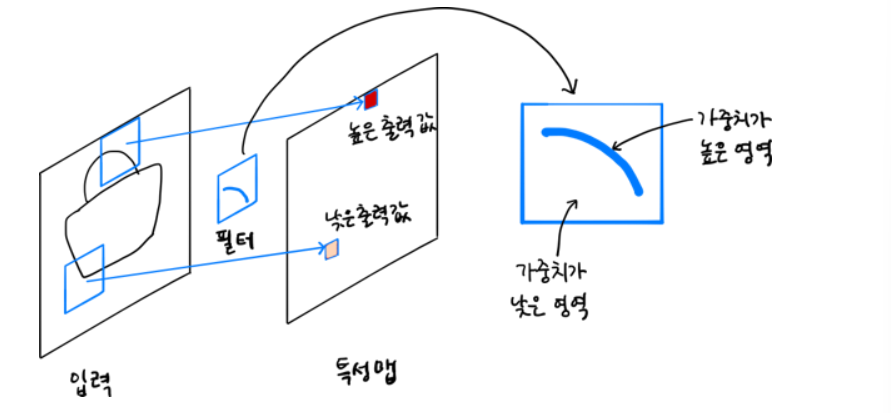

In [1]:
# 실행마다 동일한 결과를 얻기 위해, 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 생성한다.
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

from tensorflow import keras

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

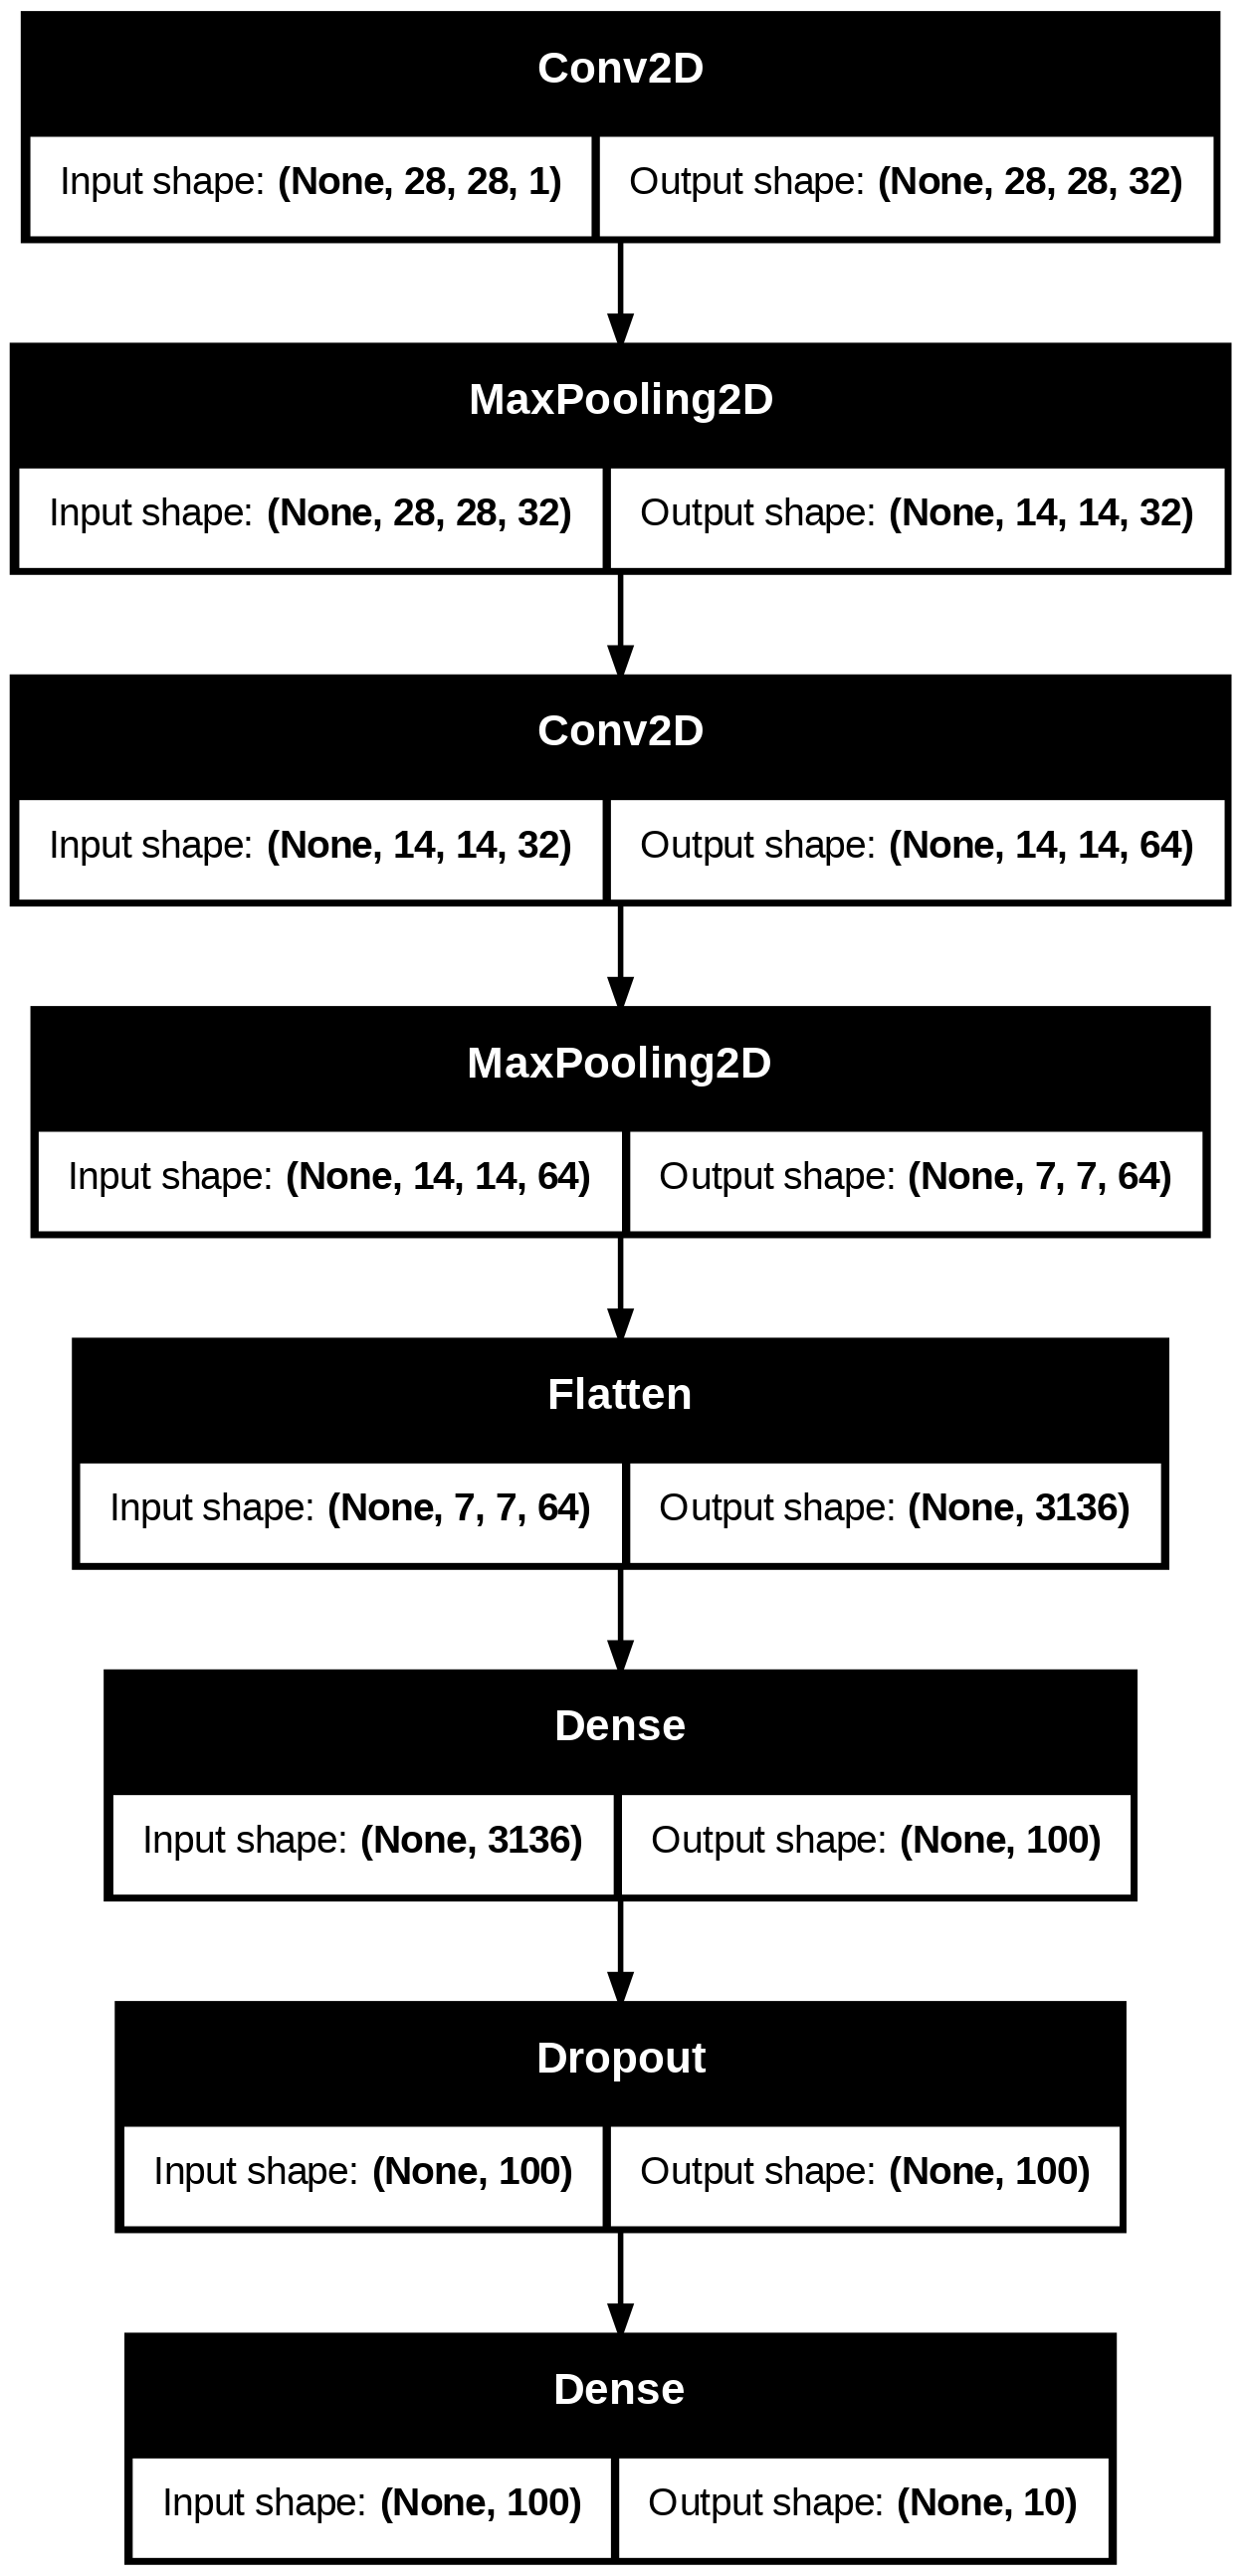

In [2]:
model = keras.models.load_model('best-cnn-model.keras') # 모델에 케라스 값을 불러온다.
model.layers
model.summary()
keras.utils.plot_model(model, show_shapes=True) # 입력과 출력의 크기를 표시한다.

# 결과
# 'model.layers' 리스트에 'Conv2D', 'MaxPoolgin2D' 층이 번갈아 가면서 나온다.
# Flatten 층 → Dense 층 → Dropout 층 → Dense 출력층

In [3]:
# 첫 번째 합성곱 층의 가중치를 알아보자.
# 층의 가중치와 절편은 층의 'weights' 속성에 있다. (리스트 타입)
conv = model.layers[0] # 1번째 도장의 크기 (커널, 필터)
print(conv.weights[0].shape, conv.weights[1].shape)

# 결과
# (3, 3, 1, 32) (32,)
#      원소      절편
# 커널의 크기를 '3 * 3'으로 설정했기 때문에, 합성곱 층의 전달되는 입력의 깊이가 1이다.
# 필터의 개수가 32개이므로 필터마다 1개의 절편이 존재한다. → (32, )

(3, 3, 1, 32) (32,)


In [4]:
conv2 = model.layers[2] # 2번째 도장의 크기 (커널, 필터)
print(conv2.weights[0].shape, conv2.weights[1].shape)

(3, 3, 32, 64) (64,)


In [7]:
# weights 속성 : 텐서플로의 다차원 배열인 Tensor 클래스의 객체이다. → 'numpy' 매서드를 사용하여 넘파이 배열로 변환한다.
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std()) # 'numpy' 매서드로 가중치 배열의 평균(mean)과 표준편차(std)를 계산한다.

# 결과 : 평균은 0에 가깝고, 편차는 0.24 정도이다.

-0.022672083 0.24381405


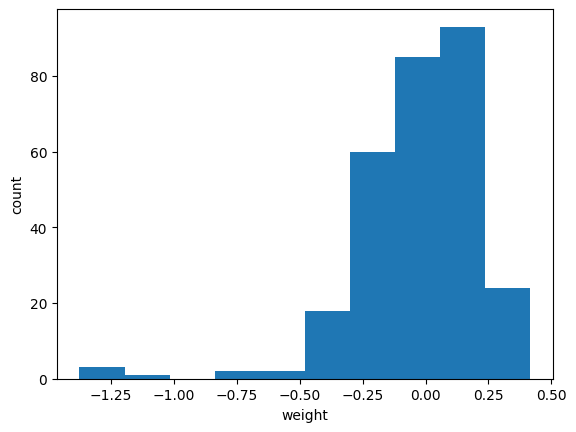

In [8]:
# 가중치가 어떤 분포를 지녔는지 직관적으로 확인해보자.
import matplotlib.pyplot as plt

# 히스토그램을 그리기 위해, 맷프롤릿의 'hist' 함수에는 1차원 배열로 전달해야 한다.
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

# 결과 : 0을 중심으로 분포도를 확인할 수 있다.

In [9]:
print(conv_weights)

# 결과 : 9개의 리스트에 32개의 값이 출력된다.

[[[[ 2.02088803e-01  1.43418983e-01  2.19320849e-01  2.29284391e-01
     1.20841131e-01 -1.61696643e-01  7.59740844e-02 -1.29516209e-02
    -1.84966177e-01 -1.30574688e-01 -3.13999325e-01 -2.37064481e-01
     3.21709886e-02  1.02949496e-02  2.37209365e-01 -1.06831527e+00
     1.49217084e-01  1.28653198e-01 -2.32722625e-01  3.59055810e-02
     4.12201658e-02  1.01128429e-01  9.12226620e-04  2.69055158e-01
     6.95954412e-02  1.08595088e-01  4.20145318e-02 -1.35924041e-01
     5.33467457e-02 -2.50822329e-03 -1.89365476e-01  2.87956763e-02]]

  [[ 3.28123540e-01  3.11297357e-01 -1.33119181e-01 -2.98786551e-01
    -2.34038830e-01 -1.89911216e-01 -3.33777117e-03 -8.77450854e-02
    -4.69493449e-01  2.21667171e-01  7.01824427e-02  1.18317991e-01
     3.62226404e-02  2.34399870e-01 -8.75496715e-02 -8.36041510e-01
    -1.31508067e-01 -1.13000624e-01  1.90599576e-01  7.77340233e-02
     1.88543543e-01  4.48442856e-03  1.67473733e-01  2.63023317e-01
     1.16015606e-01  2.63124973e-01  1.985211

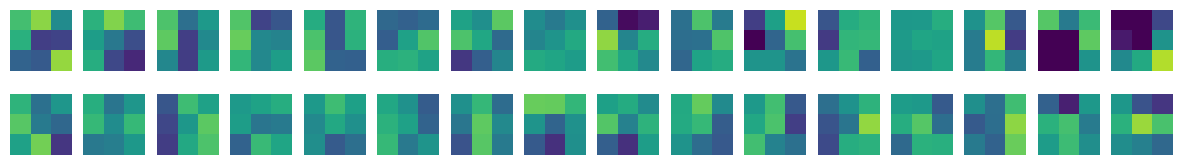

In [10]:
# 32개의 커널을 16개씩 두 줄에 출력해보자.
fig, axs = plt.subplots(2, 16, figsize=(15, 2))

# 32개(2 * 16)의 그래프 영역을 만들고 난 후, 순서대로 커널을 출력해보자.
for i in range(2) : # i : 행의 인덱스 (0 ~ 1)
    for j in range(16) : # j : 열의 인덱스 (0 ~ 15)
       axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5) # (0, 0) ~ (0, 31)
       axs[i, j].axis('off')

plt.show()

# 결과 : 특정 패턴이 출력된다.

In [11]:
# 훈련하지 않은 빈 합성곱 신경망을 만들어보자.
no_training_model = keras.Sequential()

no_training_model.add(keras.layers.Conv2D(
    32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1))) # Conv2D 층을 추가한다.

no_training_conv = no_training_model.layers[0] # 'no_training_conv' 변수에 Conv2D 층의 가중치를 저장한다.

print(no_training_conv.weights[0].shape) # (3, 3) 커널을 지닌 필터를 32개 사용한다.

(3, 3, 1, 32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 가중치의 평균과 표준편차를 확인해보자.
no_training_weights = no_training_conv.weights[0].numpy() # 넘파이 배열로 만든다.
print(no_training_weights.mean(), no_training_weights.std())

# 결과 : 평균은 0에 가깝고, 편차는 매우 작다.

0.0053191613 0.08463709


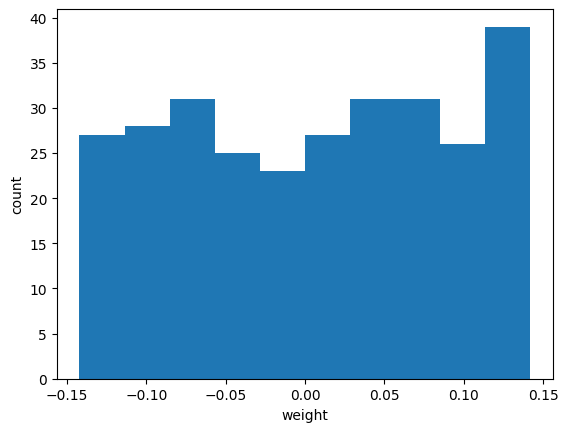

In [13]:
# 가중치 배열을 히스토그램으로 출력해보자.
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

# 결과
# 대부분의 가중치가 '-0.15 ~ 0.15' 사이에 존재한다.
# 텐서플로가 신경망의 가중치를 처음에 초기화할 때 균등하게 값을 선택하기 때문에, 비교적 고른 분포도를 보인다.

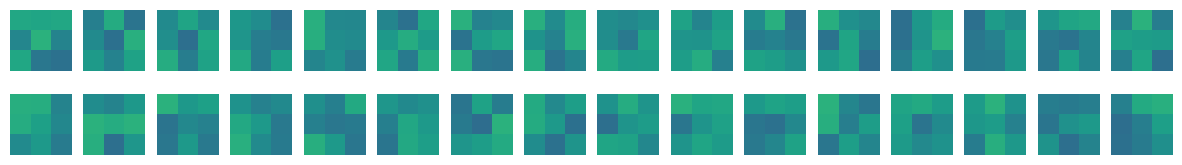

In [14]:
# 'imshow' 함수를 활용하여 그림으로 출력해보자.
fig, axs = plt.subplots(2, 16, figsize = (15, 2))

for i in range(2) :
  for j in range(16) :
    axs[i, j].imshow(no_training_weights[:, :, 0, i * 16 + j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')

plt.show()

# 결과 : 분류 정확도를 높이기 위해 유용한 패턴을 학습했다.

In [ ]:
# 함수형 API : 케라스의 내장형 함수 → 케라스의 'Model' 클래스를 사용하여 모델을 생성한다.
# 케라스의 Sequential 클래스 : 층을 차례대로 쌓은 모델을 생성한다.

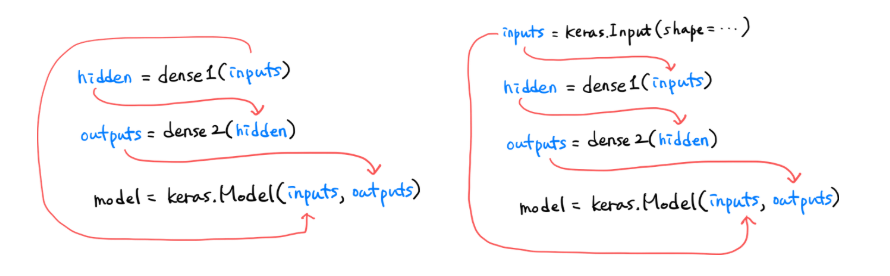

In [ ]:
# Dense 층이 2개로 이루어진 완전 연결 신경망을 함수형 API로 구현했다.
# Dense 층 각각에서 객체를 만들고, 'keras.Model'의 파라미터로 제공한다.
# 입력에서 출력까지 층을 호출한 결과물을 계속 이어주고, 'Model' 클래스에 입력과 최종 출력을 지정한다.

In [ ]:
# 함수형 API가 필요한 이유

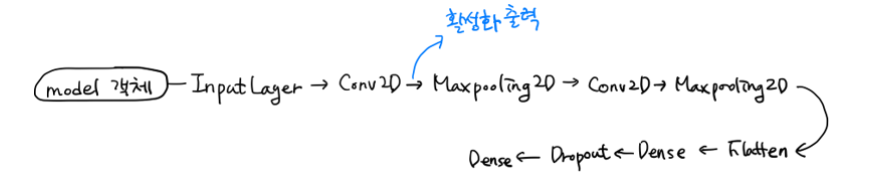

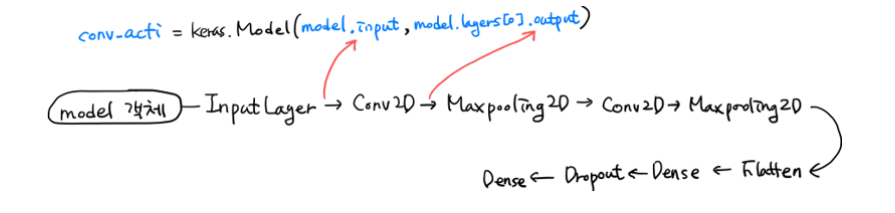

In [15]:
# model 객체를 'predict' 매서드로 호출하면 마지막 층까지 모든 계산을 수행한 후 최종 출력을 반환한다.
# 그러나 우리는 첫 번째 'Conv2D' 층에서 출력된 특성 맵이 필요하기 때문에, 'model.layer[0].output'을 참조한다.
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]


In [17]:
# 'model.input'과 'model.layers[0].output'을 연결하는 새로운 'conv_acti' 모델을 생성해보자.
conv_acti = keras.Model(model.inputs, model.layers[0].output)

In [22]:
# 특성 맵을 시각화 해보자. → 케라스를 통해 패션 MNIST 데이터 셋을 읽은 후, 훈련 세트에 존재하는 첫 번째 샘플을 그린다.
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

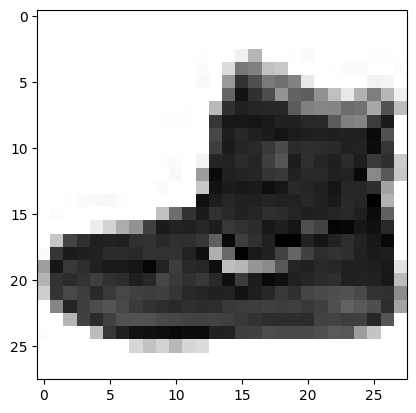

In [23]:
# 첫 번째 샘플을 출력한다.
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [25]:
# 위의 샘플을 'conv_acti' 모델에 주입하고, 'Conv2D' 층이 만드는 특성 맵을 출력해보자.
# 'predict' 매서드는 항상 입력의 첫 번째 차원을 배치 차원으로 여기기 때문에, 하나의 샘플을 전달하더라도 반드시 첫 번째 차원을 유지해야 한다. → 슬라이싱 연산자를 통해 첫 번째 샘플을 선택한다.
inputs = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


In [26]:
print(feature_maps.shape) # maps의 크기를 확인한다.

# 결과 : (1,   28, 28,   32)
#        개수   크기   특성 도장 개수

(1, 28, 28, 32)


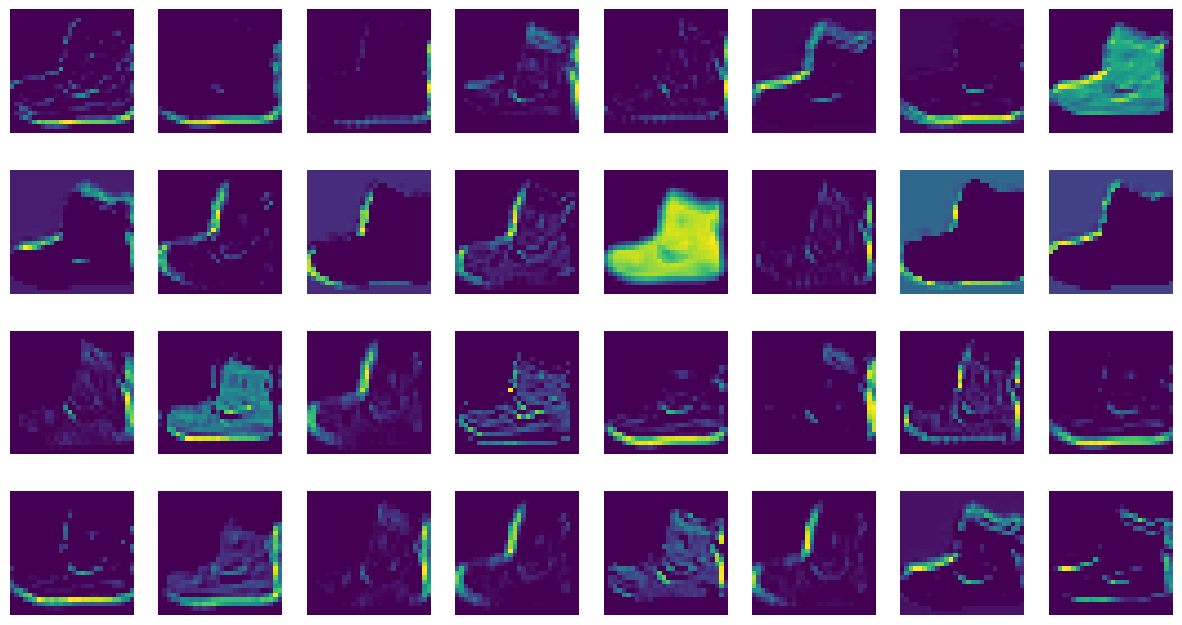

In [27]:
# 맷플롯립의 'imshow' 함수로 특성 맵을 그려보자. → 총 32개의 특성 맵이 존재하므로, 4행으로 나누어 출력한다.
fig, axs = plt.subplots(4, 8, figsize=(15, 8))

for i in range(4) :
  for j in range(8) :
    axs[i, j].imshow(feature_maps[0, :, :, i * 8 + j])
    axs[i, j].axis('off')

plt.show()

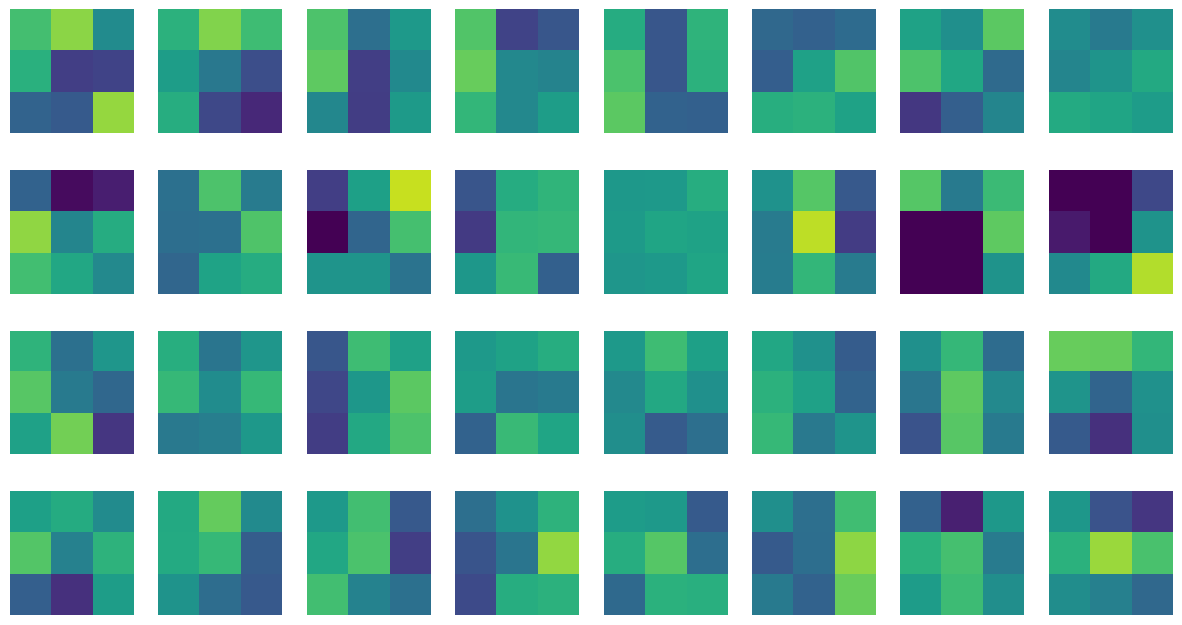

In [28]:
# 특성 맵과 비교해보자.
fig, axs = plt.subplots(4, 8, figsize=(15, 8))

for i in range(4) :
  for j in range(8) :
    axs[i, j].imshow(conv_weights[:, :, 0, i * 8 + j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')

plt.show()

In [34]:
# 두 번쨰 합성곱 층이 생성한 특성 맵 또한 동일한 방식으로 확인할 수 있다.
# 'model' 객체의 입력과 두 번째 합성곱 층인 'model.layer[2]'의 출력을 연결한 'conv2_acti' 모델을 생성한다.
conv2_acti = keras.Model(model.inputs, model.layers[2].output)

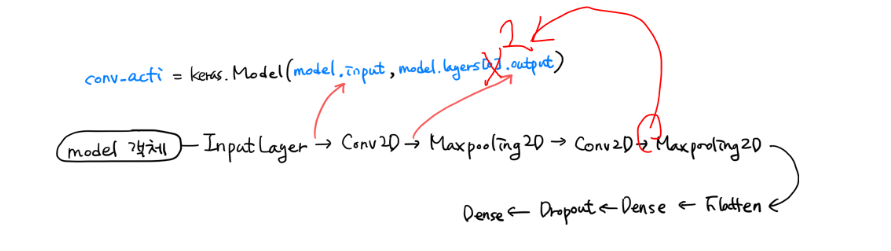

In [35]:
# 첫 번째 샘플을 'conv2_acti' 모델의 'predict' 매서드에 전달한다.
feature_maps = conv2_acti.predict(train_input[0:1].reshape(-1, 28, 28, 1) / 255.0)
print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(1, 14, 14, 64)


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

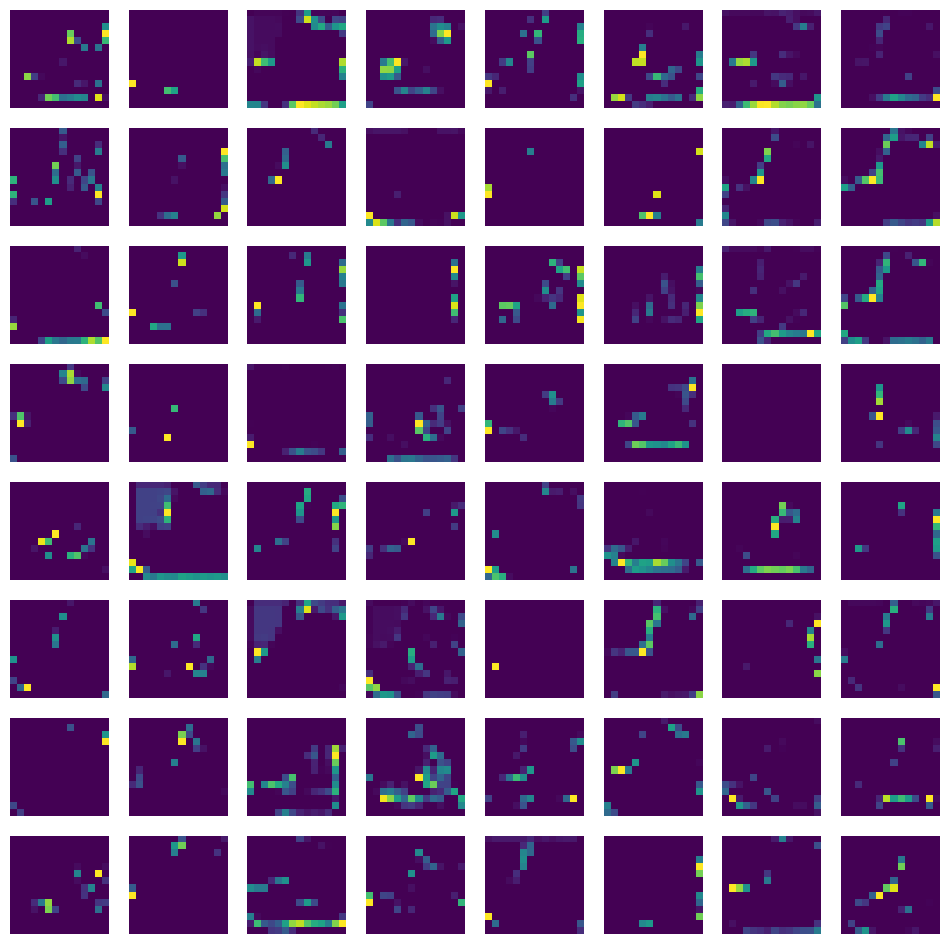

In [38]:
# 64개의 특성 맵을 8개씩 나누어 'imshow' 함수로 그려보자.
fig, axs = plt.subplots(8, 8, figsize = (12, 12))

for i in range(8) :
  for j in range(8) :
    axs[i, j].imshow(feature_maps[0, :, :, i * 8 + j])
    axs[i, j].axis('off')

plt.show()

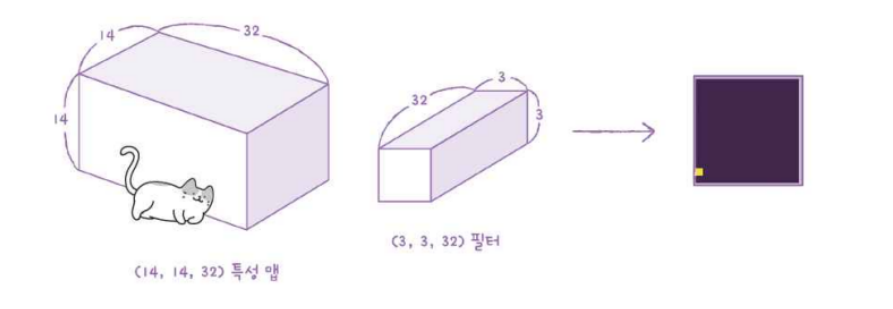